# Objetivo: 
Este notebook tiene como objetivo:
1. Explorar el framework de LlamaIndex con Ollama.
- `LlamaIndex` es un framework de desarrollo de aplicaciones basadas en LLMs.
- `Ollama` es una herramienta que permite descargar,  ejecutar e interactuar con LLMs en la tu máquina local.
2. Explorar el modelo multimodal LlaVA 1.6
- version 7B
- version 13B
- version 34 B

# Funciones  para trabajar con imágenes

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

def show_image(image_path):
    """ show image """
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(16, 5))
    plt.imshow(image)

In [2]:
def resize_image(image_path):
    """ Resize image to 224x224"""
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224)) 
       
    return image

# LLms de Ollama usando LlamaIndex

# LLaVA 1.6 :
LLaVA is a novel end-to-end trained large multimodal model that combines a vision encoder and Vicuna for general-purpose visual and language understanding. https://ollama.com/library/llava

* ### Modelo 1: LlaVA 1.6 - 7B
`ollama run llava:7b`

* `Objetivo`: probar el modelo multimodal Llava 1.6,  utilizando la clase Ollama para usar texto como dato de entrada.

In [4]:
from llama_index.llms.ollama import Ollama

llm = Ollama(model="llava:7b", request_timeout=60.0)

response = llm.complete("What is the capital of France?")
print(response)

 The capital city of France is Paris. 


* `Objetivo`: probar el modelo multimodal Llava 1.6,  utilizando la clase OllamaMultimodal para usar una imagen como dato de entrada y un prompt como intrucción base
para el modelo.

 La imagen muestra una pareja de zapatos deportivos en un color blanco con accesorios verdes. Cada zapato lleva la marca "STELLA", y el texto "MADRAGA" se encuentra en la parte superior del lateral izquierdo de cada zapato. La imagen es una promoción publicitaria, ya que se puede leer "Stella Madraga", lo que indica un modelo o estilo de los zapatos llamado así. El fondo es una superficie de color neutro y no hay ningún otro objeto en la imagen. 


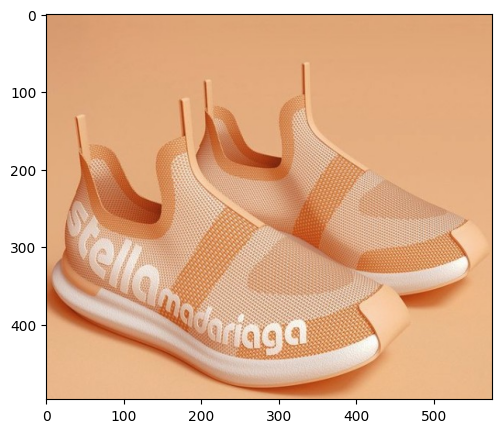

In [15]:
from llama_index.multi_modal_llms.ollama import OllamaMultiModal
from llama_index.core import SimpleDirectoryReader
from pprint import pprint
# put your local directore here
image_documents = SimpleDirectoryReader(
    input_files=["../data/5.jpg"]
).load_data()

# loadd the multimodal model
mm_model = OllamaMultiModal(model="llava:7b", request_timeout=60.0)

# invoke the multimodal model
response = mm_model.complete(
    prompt="Describe en 10 palabras esta imagen en español de forma precisa y concisa ",
    image_documents=image_documents,
)

# print the response
print(response)
# show the image
show_image("../data/5.jpg")

* ### Modelo 1: LlaVA 1.6 - 13B
`ollama run llava:13b`

 Dos zapatos deportivos con diseño futurista, en color naranja claro. El logo "Stella McCartney" está visible en ambos zapatos.


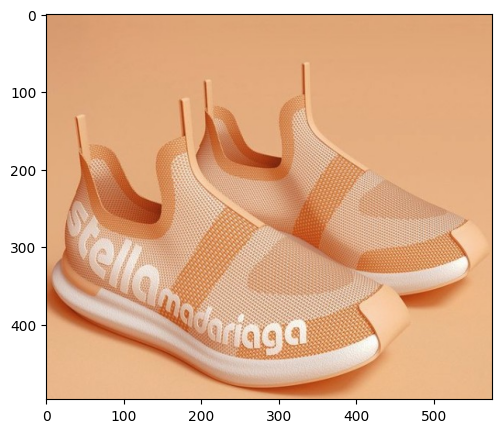

In [14]:
from llama_index.multi_modal_llms.ollama import OllamaMultiModal
from llama_index.core import SimpleDirectoryReader
from pprint import pprint
# put your local directore here
image_documents = SimpleDirectoryReader(
    input_files=["../data/5.jpg"]
).load_data()

# loadd the multimodal model
mm_model = OllamaMultiModal(model="llava:13b", request_timeout=60.0)

# invoke the multimodal model
response = mm_model.complete(
    prompt="Describe en pocas palabras esta imagen en español de forma precisa y concisa ",
    image_documents=image_documents,
)

# print the response
print(response)
# show the image
show_image("../data/5.jpg")

* ### Modelo 1: LlaVA 1.6 - 34B
`ollama run llava:34b`

`input data`: ../data/5.jpg

Imagen de un par de zapatillas color naranja con detalles de textura y letra en blanco.


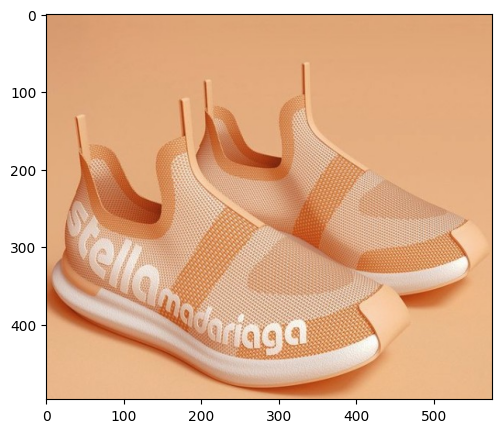

In [16]:
from llama_index.multi_modal_llms.ollama import OllamaMultiModal
from llama_index.core import SimpleDirectoryReader
from pprint import pprint
# put your local directore here
image_documents = SimpleDirectoryReader(
    input_files=["../data/5.jpg"]
).load_data()

# loadd the multimodal model
mm_model = OllamaMultiModal(model="llava:34b", request_timeout=60.0)

# invoke the multimodal model
response = mm_model.complete(
    prompt="Describe en pocas palabras esta imagen en español de forma precisa y concisa ",
    image_documents=image_documents,
)

# print the response
print(response)
# show the image
show_image("../data/5.jpg")

`input data`: ../data/2.jpg

La imagen muestra un modelo de botín con una talla que indica que es número 7. Está decorado con rosas en el lado del pie y la parte superior, y está hecho de tela con trama que parece ser denim. La botella tiene un patrón imitando cuero con suave textura. El interior del pie es blanco, mientras que la parte inferior es de color negro.


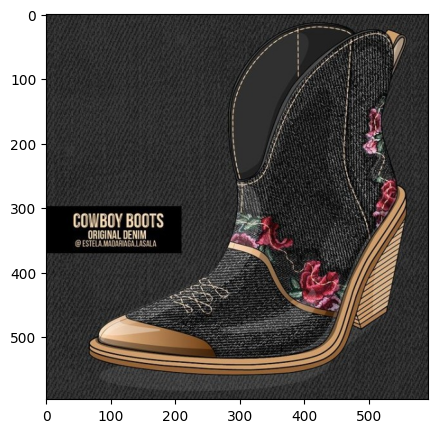

In [18]:
from llama_index.multi_modal_llms.ollama import OllamaMultiModal
from llama_index.core import SimpleDirectoryReader
from pprint import pprint
# put your local directore here
image_documents = SimpleDirectoryReader(
    input_files=["../data/2.jpg"]
).load_data()

# loadd the multimodal model
mm_model = OllamaMultiModal(model="llava:34b", request_timeout=60.0)

# invoke the multimodal model
response = mm_model.complete(
    prompt="Describe en pocas palabras esta imagen en español de forma precisa y concisa",
    image_documents=image_documents,
)

# print the response
print(response)
# show the image
show_image("../data/2.jpg")

* `Prueba 2`: Redimensionar la imagen

<class 'PIL.Image.Image'>


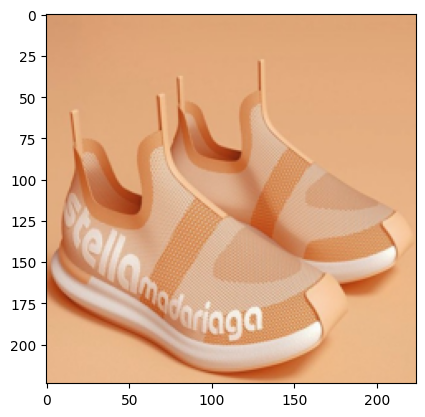

In [19]:
image_resized = resize_image("../data/5.jpg")
print(type(image_resized))
plt.imshow(image_resized)
image_resized.size
image_resized.save("../data/5_small.jpg")

The image shows a pair of white sneakers with black text and design elements. The shoes feature an upper that appears to have a mix of solid material and what might be mesh or perforated sections, allowing for breathability. The brand name is visible in black lettering on the sides. The sole of the shoe is also white and has a textured pattern. The background of the image is not clearly distinguishable due to the focus on the sneakers.


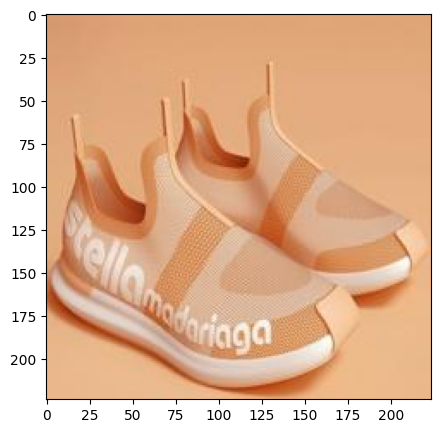

In [21]:
image_documents = SimpleDirectoryReader(
    input_files=["../data/5_small.jpg"]
).load_data()

# loadd the multimodal model
mm_model = OllamaMultiModal(model="llava:34b", request_timeout=60.0)

# invoke the multimodal model
response = mm_model.complete(
    prompt="Describe the image briefly.",
    image_documents=image_documents,
)

# print the response
print(response)
# show the image
show_image("../data/5_small.jpg")

# LLms usando Ollama

In [23]:
import ollama

In [33]:
respuesta =ollama.chat(
    model="llava:7b",
    messages=[
        {"role": "user", "content": "¿Cuál es la capital de España?"}],
    stream=False
)
print(respuesta['message']['content'])

 La capital de España es Madrid. 


In [34]:
stream =ollama.chat(
    model="llava:7b",
    messages=[
        {"role": "user", "content": "¿Cuál es la capital de España?"}],
    stream=True
)

for chunk in stream:
    print(chunk['message']['content'],end="", flush=True)

 La capital de España es Madrid. 

In [35]:
respuesta =ollama.chat(
    model="llava:7b",
    messages=[
        {"role": "user", "content": "Describe the image.","images": ['../data/5.jpg']}],
    stream=False
)
print(respuesta['message']['content'])

 The image shows a pair of shoes displayed against a plain background with a pink gradient hue from top to bottom. The shoes are designed to resemble a sock, as they have an open-toe design and are not enclosed in any rigid structure like traditional sneakers. They feature a prominent brand name on the side, which is partially obscured but appears to read "STELLA" in capital letters, with the remainder of the text being cut off by the frame of the image. The soles of the shoes have an orange hue and bear the brand name in white letters. There's also a small graphic element on the sole that seems to resemble a flower or a decorative pattern. The upper part of the shoe has a transparent mesh-like material, which could suggest a breathable design, and the color scheme includes shades of pink, orange, and a hint of brown or tan. The overall style of the image is clean and product-focused, likely intended for an advertisement or e-commerce listing to showcase the shoes' design and branding.

In [30]:
respuesta =ollama.chat(
    model="llava:7b",
    messages=[
        {"role": "user", "content": "Describe the image without mentioning the author. Respond in spanish","images": ['../data/2.jpg']}],
    stream=False
)
print(respuesta['message']['content'])

 La imagen muestra un zapato de cowboy con una detallada decoración de flores rojas y una banda en la parte superior del zapato. El zapato está adornado con una banderita en la parte inferior que dice "Original Denim". A continuación, se puede ver la palabra "Cowboy Boots" impresa sobre el fondo. El estilo de la imagen es un estilo gráfico o digital con una composición sencilla y directa que destaca el zapato y su decoración. 


In [31]:
respuesta =ollama.chat(
    model="llava:13b",
    messages=[
        {"role": "user", "content": "Describe the image without mentioning the author. Respond in spanish","images": ['../data/2.jpg']}],
    stream=False
)
print(respuesta['message']['content'])

 La imagen muestra un par de botas de cowboy estilo moderno diseñadas para mujeres. Están hechas de material denim negro con una textura que sugiere la calidad y el uso duradero típico de este material. En lugar de rosas convencionales, las botas tienen adornos florales estilizados en un diseño más contemporáneo, lo cual les da un aspecto sofisticado y elegante. Además, la parte superior de las botas tiene una suave curva para un ajuste cómodo y se abotonan con ojitos que le dan un estilo urbano y chic. La imagen está rodeada por una descripción en texto que indica "BOOTS COWBOY CON FLORAS", lo cual es claramente el tipo de calzado representado.


In [32]:
respuesta =ollama.chat(
    model="llava:34b",
    messages=[
        {"role": "user", "content": "Describe the image without mentioning the author. Respond in spanish","images": ['../data/2.jpg']}],
    stream=False
)
print(respuesta['message']['content'])

La imagen muestra una pieza de calzado, específicamente un par de botines tipo cowboy, que está diseñado para ser una representación del estilo ranchero o country. Los botines son de tela con texturas similares a la seda, cubiertos con una imagen floral y colorida en el lado exterior, que sugiere un toque más elegante y fashionista al clásico modelo. La parte superior del botín tiene bordes de cuero marron y está decorada con botones similares a los que se pueden ver en una camisa de campana, lo que agrega aún más detalles rancheros al diseño. Los botines también son hechos de material que imita la seda, y el empaque entero sugiere un cuidadoso proceso de creación artesanal.
